In [1]:
import nltk
import numpy as np
import pandas as pd
import os
import re
import Basic_functions as bf  #Homemade script.
import time

import matplotlib.pyplot as plt


from nltk import word_tokenize
from nltk.tokenize import WordPunctTokenizer
from nltk.corpus import stopwords
from nltk.tokenize import word_tokenize
from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from nltk.stem import SnowballStemmer



###################################################

#https://gist.github.com/berteltorp/0cf8a0c7afea7f25ed754f24cfc2467b Stopords liste
stopwords_danish = np.genfromtxt(r"stopord.txt", dtype = "str", encoding="utf-8")
default_stopwords = set(stopwords.words('english'))

extended_stopwords = default_stopwords.union(stopwords_danish)

In [11]:
#test = open("Speeches\A._Bartholdy_Møllers_prædiken_1._søndag_efter_paske.txt", "r", encoding="utf-8").read().strip()

def import_txt_files_to_array(folder_path):
    txt_files_content = []
    txt_year          = []
    Files_read = 0

    for filename in os.listdir(folder_path):
        if filename.endswith('.txt'):
            Files_read = Files_read + 1
            file_path = os.path.join(folder_path, filename)
            try:
                with open(file_path, 'r', encoding='utf-8') as file:
                    content = file.read()
                    # Split at the first occurrence of "\n\n\n" and take the part after it
                    parts = content.split('\n\n\n', 1)
                    if len(parts) > 1:
                        text_after_marker = parts[1]
                    else:
                        text_after_marker = content  # Fallback if "\n\n\n" not found

                    # Replace escaped newlines (\\n) with spaces, then remove all newlines
                    text_after_marker = text_after_marker.replace('\\n', ' ').replace('\n', ' ')

                    # Convert to lowercase, keep letters (including æøå), spaces, and remove ellipses
                    cleaned_text = re.sub(r'[^a-zA-ZæøåÆØÅ\s]', '', text_after_marker.lower())
                    cleaned_text = cleaned_text.replace("'", "")
                    cleaned_text = cleaned_text.replace('...', '')  # Remove ellipses

                    # Remove extra spaces (e.g., multiple spaces)
                    cleaned_text = ' '.join(cleaned_text.split())

                    txt_files_content.append(cleaned_text)


                    ############################################

                    year_part = content.split('\n', 2)
                    year_after_marker = (year_part[1].split('-',1))[0]
                    cleaned_year = year_after_marker.replace('Date: ', "")
                    try:
                        txt_year.append(float(cleaned_year))
                    except:
                        txt_year.append(0)
                    
            except Exception as e:
                print(f"Error reading {filename}: {e}")
    print('Files read:', Files_read)

    return  pd.DataFrame(txt_files_content, columns = ['text']), pd.DataFrame(txt_year, columns = ['year'])

# Example usage:
folder_path = r'C:\Users\Geniet\AppliedML\AppML_Project\ML2026_Project\Speeches'  # Replace with your folder path
df, df_year = import_txt_files_to_array(folder_path)

print('done')
#skip = test.find('\n\n\n')
#Raw_test = test[skip:].lower()
#nltk.download('all')


Files read: 4753
done


In [13]:
len(df_year)

4753

In [15]:
def preprocess(text):
    stemmer = SnowballStemmer(language='danish')
    
    tokens = word_tokenize(text)
    tokens = [word for word in tokens if word.isalpha() and word not in extended_stopwords]
    tokens = [stemmer.stem(word) for word in tokens]
    return " ".join(tokens)
    

####################################

#df2 = pd.DataFrame(df, columns = ['text'])

start = time.time()

df_clean = pd.DataFrame({
    'text': df['text'].apply(preprocess),
    'year': df_year['year']
})

#df_clean = df2['text'].apply(preprocess)
#df_clean = pd.DataFrame(df_clean, columns = ['text'])
#dfpd_year = pd.DataFrame(df_year, columns = ['year'])
#dfpd = pd.concat([df_clean, dfpd_year], axis = 1)
    
stop = time.time()

print(f'Time preprocessing: {stop-start:3f} seconds')

Time preprocessing: 82.669317 seconds


In [17]:
df_clean

,text,year
0,landsmænd dansk student fædreland skyld udret ...,1942.0
1,udpræg centralt skøn evangelium kristus saml f...,1945.0
2,syndsforlad naad fortælling jesu mød synderind...,1944.0
3,ord indehold her forjæt jesus gav discipl foru...,1945.0
4,god livsråd grønland fremtid bær ansvar ældr g...,2025.0
...,...,...
4748,oh thank much dont know say heart jumping uhør...,2022.0
4749,excellenci distinguis delegat partn three deca...,2024.0
4750,toward green reading european chart local self...,2022.0
4751,ret uddan børn sær pig vigt ret verdenssamfund...,2022.0


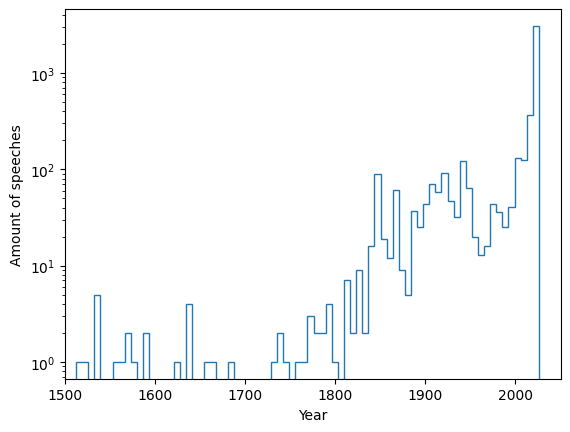

In [19]:
plt.hist(df_clean['year'], bins = 300, histtype = 'step')
plt.yscale('log')
plt.xlim(1500,2050)
plt.xlabel('Year')
plt.ylabel('Amount of speeches')
plt.show()

In [21]:
vectorizer = TfidfVectorizer(use_idf=False, lowercase=True, token_pattern=r'(?u)\b[A-Za-zæøå]+\b')
X = vectorizer.fit_transform(df_clean['text'])
y = df_clean['year']
print("TF-IDF matrix shape:", X.shape) # 174594 words is too much >:(

TF-IDF matrix shape: (4753, 112273)


In [22]:
vectorizer.get_feature_names_out()

array(['aa', 'aaand', 'aaarsag', ..., 'øyet', 'øyn', 'øånd'], dtype=object)

In [27]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.25, random_state=42)

In [126]:
import xgboost as xgb
from sklearn.metrics import mean_squared_error, r2_score
print(xgb.__version__)

model = xgb.XGBRegressor(objective='reg:squarederror',
                         eval_metric = 'rmse',
                         importance_type="weight",
                         n_estimators=100,
                         learning_rate=0.2,
                         max_depth = 10,
                         reg_alpha = 0.7,
                         subsample = 0.8,
                         #early_stopping_rounds = 10,
                         random_state=42)
start = time.time()

model.fit(X_train, y_train)

stop = time.time()
print(f'Training time: {stop - start:3f} seconds')

y_pred = model.predict(X_test)

rmse = np.sqrt(mean_squared_error(y_test, y_pred))
r2 = r2_score(y_test, y_pred)

print(f'RMSE: {rmse:.3f}')
print(f'R²: {r2:.3f}')

model.save_model('model.bin')

3.0.0
Training time: 94.499261 seconds
RMSE: 48.581
R²: 0.640


C:\Users\Geniet\AppliedML\AppliedML2026\appmlenv\Lib\site-packages\xgboost\sklearn.py:1028: UserWarning: [22:11:21] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\c_api\c_api.cc:1427: Saving model in the UBJSON format as default.  You can use file extension: `json`, `ubj` or `deprecated` to choose between formats.
  self.get_booster().save_model(fname)


In [128]:
# Retrieve the "gain" feature importance scores
importance_scores = model.feature_importances_

# Print the feature importance scores along with feature names
Importance_labels = np.argsort(importance_scores)[-100:]
print(vectorizer.get_feature_names_out()[Importance_labels])
print(importance_scores[Importance_labels])
#for feature, score in zip(vectorizer.get_feature_names_out(), importance_scores):
#    print(f"{feature}: {score}")

['frygt' 'mød' 'ting' 'men' 'maa' 'radio' 'indsat' 'altsam' 'fuld'
 'altsaa' 'bidrag' 'gjør' 'absurd' 'liv' 'gaml' 'hense' 'drøm' 'je' 'børn'
 'advok' 'befolkning' 'kvind' 'gud' 'aabenbart' 'afklaring' 'gæld' 'sand'
 'tag' 'danmark' 'hjert' 'hvorled' 'anderled' 'tal' 'mennisk' 'lov' 'hjem'
 'barn' 'god' 'afhæng' 'aft' 'grund' 'glæd' 'aa' 'att' 'afhold' 'afstand'
 'abstrak' 'giv' 'find' 'brug' 'kær' 'kald' 'føl' 'afpres' 'hurra' 'sidst'
 'sid' 'aalborg' 'sag' 'handl' 'hold' 'betyd' 'paa' 'anstændighedsføl'
 'aabent' 'bedst' 'land' 'frem' 'blev' 'begynd' 'adfærd' 'aarhus' 'alvor'
 'dansk' 'folk' 'saa' 'almind' 'adskil' 'dag' 'amen' 'tid' 'tak' 'ansvar'
 'undersåt' 'bedr' 'begejstringsråb' 'mennesk' 'bedrag' 'athen' 'argo'
 'aab' 'absolut' 'adgang' 'aabn' 'aabenbar' 'arbejd' 'accept' 'aand' 'aar'
 'afgør']
[0.00170565 0.00170565 0.00170565 0.00170565 0.00170565 0.00170565
 0.00170565 0.00170565 0.00170565 0.00170565 0.00170565 0.00170565
 0.00170565 0.00170565 0.00170565 0.00170565 0.0017

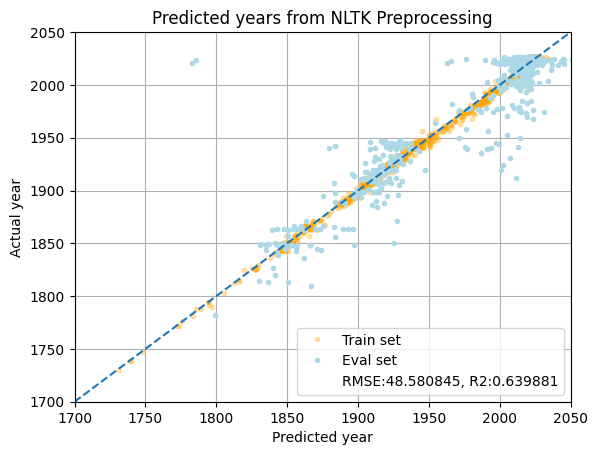

In [130]:
lim = np.array([[1700,1700],[2050,2050]])
#plt.plot(y_pred,y_test, '.', label = 'Eval set')
y_train_pred = model.predict(X_train)
plt.plot(y_train_pred, y_train, '.', alpha = 0.3, c = 'orange', label = 'Train set')
plt.plot(y_pred,y_test, '.', c= 'lightblue', label = 'Eval set')

plt.plot([1700,2050],[1700,2050], '--')
plt.xlabel('Predicted year')
plt.ylabel('Actual year')
plt.xlim(1700,2050)
plt.ylim(1700,2050)

plt.plot([],[], ' ', label = f'RMSE:{rmse:3f}, R2:{r2:3f}')
plt.grid()
plt.title('Predicted years from NLTK Preprocessing')
plt.legend()


<h1> Text Classification</h1>